In [82]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## EXPLORAÇÃO DE DADOS

In [83]:
base_credit = pd.read_csv('credit_data.csv', sep=',')

base_credit

,clientid,income,age,loan,default
0,1,66155.925095,59.017015,8106.532131,0
1,2,34415.153966,48.117153,6564.745018,0
2,3,57317.170063,63.108049,8020.953296,0
3,4,42709.534201,45.751972,6103.642260,0
4,5,66952.688845,18.584336,8770.099235,1
...,...,...,...,...,...
1995,1996,59221.044874,48.518179,1926.729397,0
1996,1997,69516.127573,23.162104,3503.176156,0
1997,1998,44311.449262,28.017167,5522.786693,1
1998,1999,43756.056605,63.971796,1622.722598,0


In [84]:
# income : renda anual
# loan : dívida
# default : 0 - empresetimo pago, 1 - esprestimo não pago

In [85]:
base_credit.sample(5)

,clientid,income,age,loan,default
291,292,67879.248019,43.597209,10433.474345,0
1278,1279,29410.177520,23.498165,812.323534,0
1342,1343,39545.959588,43.700867,5787.658045,0
368,369,42843.099129,28.631786,839.869024,0
209,210,58906.251686,42.049342,9290.575345,0


In [86]:
base_credit.describe()

,clientid,income,age,loan,default
count,2000.000000,2000.000000,1997.000000,2000.000000,2000.000000
mean,1000.500000,45331.600018,40.807559,4444.369695,0.141500
std,577.494589,14326.327119,13.624469,3045.410024,0.348624
min,1.000000,20014.489470,-52.423280,1.377630,0.000000
25%,500.750000,32796.459717,28.990415,1939.708847,0.000000
50%,1000.500000,45789.117313,41.317159,3974.719419,0.000000
75%,1500.250000,57791.281668,52.587040,6432.410625,0.000000
max,2000.000000,69995.685578,63.971796,13766.051239,1.000000


In [87]:
base_credit[base_credit['income'] >= 69995.685578]

,clientid,income,age,loan,default
422,423,69995.685578,52.719673,2084.370861,0


In [88]:
base_credit[base_credit['loan'] <= 1.377630	]

,clientid,income,age,loan,default
865,866,28072.604355,54.142548,1.37763,0


In [89]:
base_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   clientid  2000 non-null   int64  
 1   income    2000 non-null   float64
 2   age       1997 non-null   float64
 3   loan      2000 non-null   float64
 4   default   2000 non-null   int64  
dtypes: float64(3), int64(2)
memory usage: 78.3 KB


In [90]:
np.unique(base_credit['default'])

array([0, 1], dtype=int64)

In [91]:
base_credit['default'].value_counts()

default
0    1717
1     283
Name: count, dtype: int64

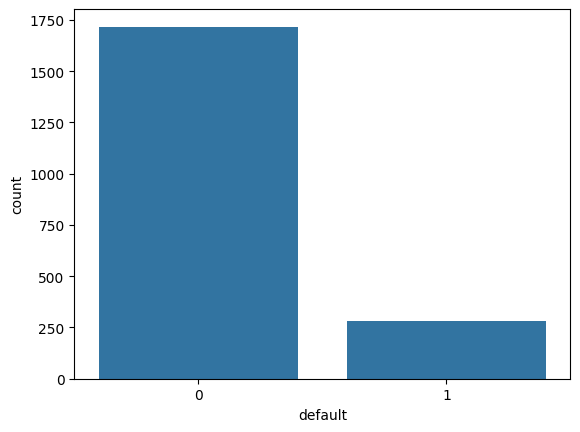

In [92]:
sns.countplot(data=base_credit, x='default');

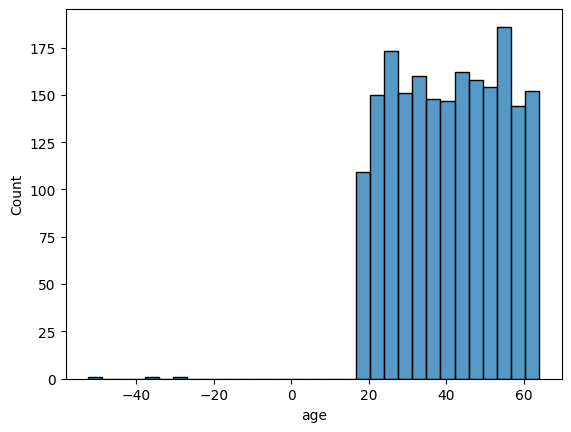

In [93]:
sns.histplot(data=base_credit, x='age');

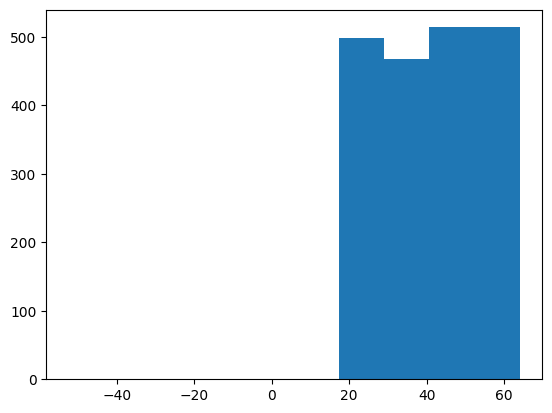

In [94]:
plt.hist(data=base_credit, x='age');

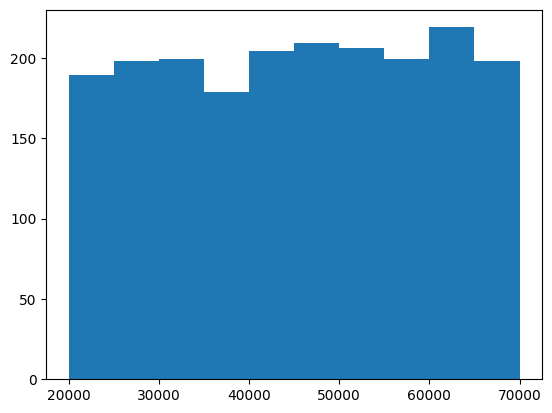

In [95]:
plt.hist(data=base_credit, x='income');

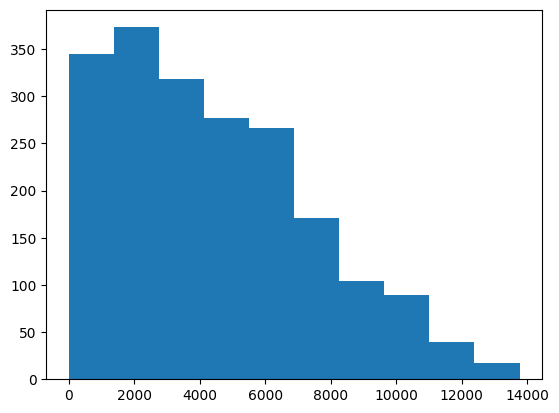

In [96]:
plt.hist(data=base_credit, x='loan');

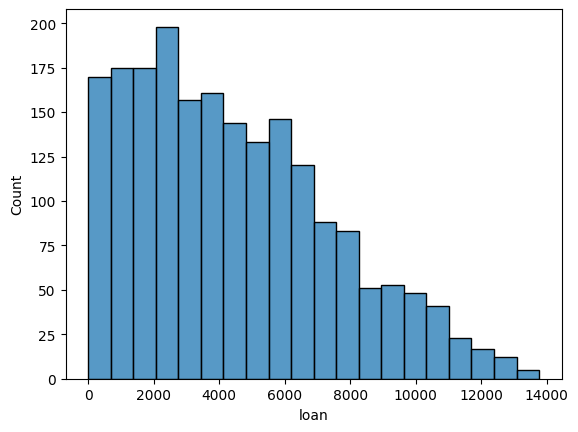

In [97]:
sns.histplot(data=base_credit, x='loan');

In [98]:
grafico = px.scatter_matrix(base_credit, dimensions=['age', 'income', 'loan'], color='default');
grafico.show()

## DATA CLEANING

In [99]:
base_credit[base_credit['age'] < 0] 

,clientid,income,age,loan,default
15,16,50501.726689,-28.218361,3977.287432,0
21,22,32197.620701,-52.423280,4244.057136,0
26,27,63287.038908,-36.496976,9595.286289,0


In [100]:
base_credit['age'] = base_credit['age'].abs()

In [101]:
base_credit[base_credit.index == 26]

,clientid,income,age,loan,default
26,27,63287.038908,36.496976,9595.286289,0


In [102]:
grafico = px.scatter_matrix(base_credit, dimensions=['age', 'income', 'loan'], color='default');
grafico.show()

In [103]:
(base_credit.isnull().sum()*100/base_credit.index.size).sort_values(ascending=False)

age         0.15
clientid    0.00
income      0.00
loan        0.00
default     0.00
dtype: float64

In [104]:
base_credit.isnull().sum()

clientid    0
income      0
age         3
loan        0
default     0
dtype: int64

In [105]:
base_credit[base_credit['age'].isnull()]

,clientid,income,age,loan,default
28,29,59417.805406,NaN,2082.625938,0
30,31,48528.852796,NaN,6155.784670,0
31,32,23526.302555,NaN,2862.010139,0


In [106]:
base_credit.dropna(subset=['age'], inplace=True)

In [107]:
base_credit[base_credit['age'].isnull()]

,clientid,income,age,loan,default


In [108]:
base_credit.isnull().sum()

clientid    0
income      0
age         0
loan        0
default     0
dtype: int64

## DIVISORES ENTRE FEATURES E TARGET

In [109]:
X_credit = base_credit.iloc[:, 1:4].values
# iloc seleciona os registro
# : -> significa todos os registros

In [110]:
y_credit = base_credit['default'].values
y_credit

array([0, 0, 0, ..., 1, 0, 0], dtype=int64)

## NORMALIZAÇÃO

In [111]:
X_credit[:, 0].min(), X_credit[:, 1].min() # menor idade

(20014.4894700497, 18.055188510566897)

In [112]:
X_credit[:, 0].max(), X_credit[:, 1].max()

(69995.6855783239, 63.971795841120205)

In [113]:
from sklearn.preprocessing import StandardScaler

scaler_credit = StandardScaler()
X_credit = scaler_credit.fit_transform(X_credit)

In [114]:
base_census = pd.read_csv('census.csv')

base_census

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [115]:
base_census.describe()

,age,final-weight,education-num,capital-gain,capital-loos,hour-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [116]:
base_census.isnull().sum()

age               0
workclass         0
final-weight      0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loos      0
hour-per-week     0
native-country    0
income            0
dtype: int64

In [117]:
base_census['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

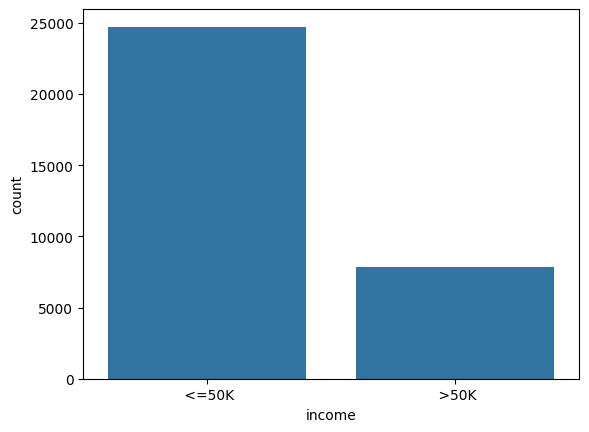

In [118]:
sns.countplot(data=base_census, x='income');

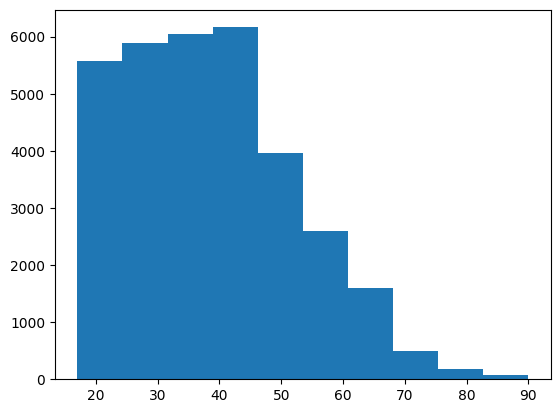

In [119]:
plt.hist(data=base_census, x='age');

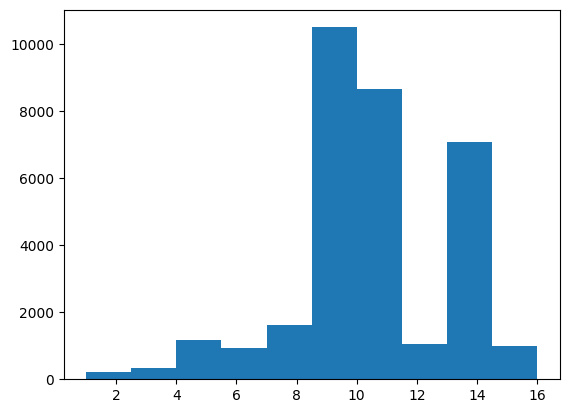

In [120]:
plt.hist(data=base_census, x='education-num');

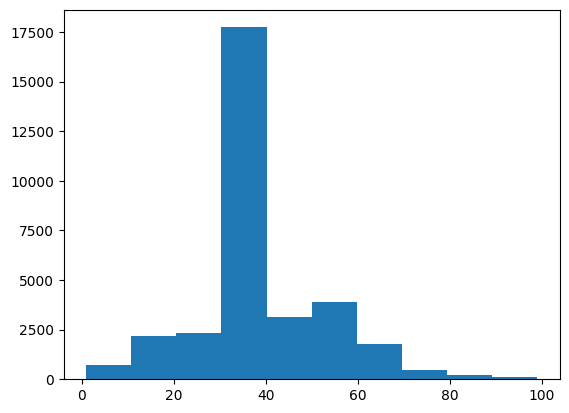

In [121]:
plt.hist(data=base_census, x='hour-per-week');

In [122]:
grafico = px.treemap(base_census, path=['workclass', 'age'])
grafico.show()

In [123]:
grafico = px.treemap(base_census, path=['occupation', 'relationship', 'age'])
grafico.show()

In [124]:
grafico = px.parallel_categories(base_census, dimensions=['occupation', 'relationship'])
grafico.show()

In [125]:
grafico = px.parallel_categories(base_census, dimensions=['workclass', 'occupation', 'income'])
grafico.show()

In [127]:
X_census = base_census.drop('income', axis=1)

In [128]:
y_census = base_census['income']

y_census

0         <=50K
1         <=50K
2         <=50K
3         <=50K
4         <=50K
          ...  
32556     <=50K
32557      >50K
32558     <=50K
32559     <=50K
32560      >50K
Name: income, Length: 32561, dtype: object

In [132]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for i in X_census.select_dtypes(exclude=['number']).columns:
    X_census[i] = label_encoder.fit_transform(X_census[i])

X_census

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country
0,39,7,77516,9,13,4,1,1,4,1,2174,0,40,39
1,50,6,83311,9,13,2,4,0,4,1,0,0,13,39
2,38,4,215646,11,9,0,6,1,4,1,0,0,40,39
3,53,4,234721,1,7,2,6,0,2,1,0,0,40,39
4,28,4,338409,9,13,2,10,5,2,0,0,0,40,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,4,257302,7,12,2,13,5,4,0,0,0,38,39
32557,40,4,154374,11,9,2,7,0,4,1,0,0,40,39
32558,58,4,151910,11,9,6,1,4,4,0,0,0,40,39
32559,22,4,201490,11,9,4,1,3,4,1,0,0,20,39


In [130]:
X_census = X_census.iloc[:, 0:14]

In [133]:
X_census.columns

Index(['age', 'workclass', 'final-weight', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loos', 'hour-per-week', 'native-country'],
      dtype='object')

In [134]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

OHE_census = ColumnTransformer(transformers=[('One Hot', OneHotEncoder(), [1, 3, 5, 6, 7, 8, 9, 13])], remainder='passthrough')

X_census = OHE_census.fit_transform(X_census).toarray()

In [135]:
X_census

array([[0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 2.1740e+03, 0.0000e+00,
        4.0000e+01],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        1.3000e+01],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        4.0000e+01],
       ...,
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        4.0000e+01],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        2.0000e+01],
       [0.0000e+00, 0.0000e+00, 0.0000e+00, ..., 1.5024e+04, 0.0000e+00,
        4.0000e+01]])

In [137]:
X_census.shape

(32561, 108)

In [138]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_census = scaler.fit_transform(X_census)

X_census

array([[-0.2444502 , -0.17429511, -0.26209736, ...,  0.1484529 ,
        -0.21665953, -0.03542945],
       [-0.2444502 , -0.17429511, -0.26209736, ..., -0.14592048,
        -0.21665953, -2.22215312],
       [-0.2444502 , -0.17429511, -0.26209736, ..., -0.14592048,
        -0.21665953, -0.03542945],
       ...,
       [-0.2444502 , -0.17429511, -0.26209736, ..., -0.14592048,
        -0.21665953, -0.03542945],
       [-0.2444502 , -0.17429511, -0.26209736, ..., -0.14592048,
        -0.21665953, -1.65522476],
       [-0.2444502 , -0.17429511, -0.26209736, ...,  1.88842434,
        -0.21665953, -0.03542945]])

In [139]:
from sklearn.model_selection import train_test_split

In [140]:
X_credit_treino, X_credit_teste, y_credit_treino, y_credit_teste = train_test_split(X_credit, y_credit, test_size=0.25, random_state=0)

In [141]:
X_credit_treino.shape

(1497, 3)

In [142]:
y_credit_treino.shape

(1497,)

In [143]:
X_credit_teste.shape, y_credit_teste.shape

((500, 3), (500,))

In [144]:
X_census_treino, X_census_teste, y_census_treino, y_census_teste = train_test_split(X_census, y_census, test_size=0.15, random_state=0)

In [145]:
X_census_treino.shape, y_census_treino.shape

((27676, 108), (27676,))

In [146]:
X_census_teste.shape, y_census_teste.shape

((4885, 108), (4885,))

In [147]:
import pickle

In [149]:
with open('credit.pkl', mode = 'wb') as f:
    pickle.dump([X_credit_treino, X_credit_teste, y_credit_teste, y_credit_treino], f)

In [ ]:
with open('census.pkl', mode = 'wb') as f:
    pickle.dump([X_census_treino, y_census_treino, X_census_teste, y_census_teste], f)